# Differential protein analysis: ALS/FTD

**Start date:** 10-10-2023

**End date:** 2024-11-20

**Analysed by:** Ruth Chia

**Working directory:** `/data/ALS_50k/OLINK/Results/Oct2023`

___


## Protein differential analysis

### Heparin/DISCOVERY (ALS vs Control)

Perform case/control analysis i.e. ALS vs controls

Standardize/scale values: `https://www.digitalocean.com/community/tutorials/normalize-data-in-r`

In [ ]:
%%bash
cd Heparin/TestCohorts/
module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(umap)

# read in pre-QC and QC-ed files
merge_norm <- fread("/data/ALS_50k/OLINK/Results/Oct2023/Heparin/OLINK_results_compiled_HEPARIN_wPCs_tidy_clean_post-bridged-normalization_wALSFRSscores_final.txt") %>%
              data.frame()

##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- merge_norm %>% select(SampleID_temp,Diagnosis,Assay,Panel,NPX,Sex,PC1,Age_Consensus,possible_outlier) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(PC1) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]]
    colnames(temp)[5] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay_Panel,-Assay,-Panel,-SampleID_temp,-Diagnosis,-Sex,-PC1,-Age_Consensus,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = do.call(cbind, datalist)

## prepare phenotype file --> generate UMAPs
## generate UMAP from all genetic PCs (then plot) for the ALS vs control cohort --> use this for correction in limma
pheno_df <- merge_norm %>%
            select(SampleID_temp,Diagnosis,Assay,Panel,Sex,Age_Consensus,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Olink_Plate_No,possible_outlier) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(PC1) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)

temp <- pheno_df %>% select(SampleID_temp,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>% distinct()
temp_umap <- scale(temp %>% select(-SampleID_temp))
temp_umap_results <- umap(temp_umap, n_components = 2)  # Reduce to 2 dimensions
temp_umap_df <- as.data.frame(temp_umap_results$layout)
colnames(temp_umap_df) <- c("UMAP1", "UMAP2")
temp_umap_df$SampleID_temp <- temp$SampleID_temp
pheno_df_updated <- merge(pheno_df,temp_umap_df, by="SampleID_temp", all.x=T)
dim(pheno_df_updated)
dim(pheno_df)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis + Age_Consensus + Sex + Olink_Plate_No + UMAP1 + UMAP2, pheno_df_updated)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(DiagnosisALS - DiagnosisControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results) %>%
              rownames_to_column(var = "Assay_Panel")
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma_excl_ouliers <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma_excl_ouliers, "ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package -- exclude potential outliers #####



# plot results
## using limma results -- exclude outliers
toplot_excl_outliers <- results_limma_excl_ouliers %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.6 | toplot_excl_outliers$log2_fold_change < -0.6), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS-heparin vs Controls-heparin\n(overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS-heparin vs Controls-heparin\n(overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        



# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS-heparin vs Controls-heparin\n(overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
iplot
htmlwidgets::saveWidget(as_widget(iplot), "ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.volcanoPlot.html")


#### heatmap

In [ ]:
%%bash
cd Heparin/TestCohorts/
module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)

merge_norm <- fread("/data/ALS_50k/OLINK/Results/Oct2023/Heparin/OLINK_results_compiled_HEPARIN_wPCs_tidy_clean_post-bridged-normalization_wALSFRSscores_final.txt")

results_limma_signif <- fread("ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                        filter(adj.P.Val < 0.05)  %>%
                        filter(logFC < -0.6 | logFC > 0.6)
df_limma <- subset(merge_norm, merge_norm$Assay %in% results_limma_signif$Assay) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(PC1) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)

heatmap <- olink_heatmap_plot(df_limma, variable_row_list = 'Diagnosis', show_rownames=FALSE)
ggsave("ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.heatmap.jpeg", heatmap, width = 16, height = 16)

In [ ]:
from IPython.display import display
from PIL import Image

results="Heparin/TestCohorts/ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg"
display(Image.open(results))

results="Heparin/TestCohorts/ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.heatmap.jpeg"
display(Image.open(results))

In [ ]:
from IPython.display import IFrame
IFrame("Heparin/TestCohorts/ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised-PC-corrected-excludedoutliers-limma.volcanoPlot.html", width=800, height=450)

### EDTA/REPLICATION (ALS vs Control)

In [ ]:
%%bash
cd EDTA_updated/TestCohorts/
module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(umap)

# read in results files
merge_norm <- fread("/data/ALS_50k/OLINK/Results/Oct2023/EDTA_updated/OLINK_results_compiled_EDTA_wPCs_tidy_clean_post-bridged-normalization_updatedDx_wALSFRSscores_final.txt")

# run step() to determine which covariates to adjust for - exclude outliers
temp <- merge_norm %>% select(SampleID_temp,Diagnosis,Sex,Age_Consensus,possible_outlier,
                              PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Consensus) & !is.na(PC1)) %>%
            filter(possible_outlier == "no") %>% distinct()
temp$CASE <- ifelse(temp$Diagnosis == "ALS", 1,0)
temp$GENDER <- ifelse(temp$Sex == "Female", 1,0)
table(temp$CASE,temp$GENDER)
table(temp$Diagnosis,temp$Sex)
model <- glm(CASE ~ GENDER + Age_Consensus + PC1 + PC2 + PC3 + PC4 + PC5 + PC6 + PC7 + PC8 + PC9 + PC10 , data = temp, family = "binomial"(link = "logit"))
summary(model)
step(model)
table(temp$CASE)

##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- merge_norm %>% select(SampleID_temp,Diagnosis,Assay,Panel,NPX,Sex,Age_Consensus,possible_outlier,PC1) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Consensus) & !is.na(PC1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[5] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay_Panel,-Assay,-Panel,-SampleID_temp,-Diagnosis,-Sex,-Age_Consensus,-possible_outlier,-PC1)
    datalist[[i]] <- temp
}
npx_df = do.call(cbind, datalist)

## prepare phenotype file
pheno_df <- merge_norm %>%
            select(SampleID_temp,Diagnosis,Assay,Panel,Sex,Age_Consensus,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Olink_Plate_No,possible_outlier) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(PC1) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)

temp <- pheno_df %>% select(SampleID_temp,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>% distinct()
temp_umap <- scale(temp %>% select(-SampleID_temp))
temp_umap_results <- umap(temp_umap, n_components = 2)  # Reduce to 2 dimensions
temp_umap_df <- as.data.frame(temp_umap_results$layout)
colnames(temp_umap_df) <- c("UMAP1", "UMAP2")
temp_umap_df$SampleID_temp <- temp$SampleID_temp
pheno_df_updated <- merge(pheno_df,temp_umap_df, by="SampleID_temp", all.x=T)
dim(pheno_df_updated)
dim(pheno_df)

## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis + Age_Consensus + Sex + Olink_Plate_No + UMAP1 + UMAP2, pheno_df_updated)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(DiagnosisALS - DiagnosisControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results) %>%
              rownames_to_column(var = "Assay_Panel")
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma_excl_ouliers <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma_excl_ouliers, "ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package -- exclude potential outliers #####

## using limma results -- exclude outliers
toplot_excl_outliers <- results_limma_excl_ouliers %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.6 | toplot_excl_outliers$log2_fold_change < -0.6), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS-EDTA vs Controls-EDTA\n(overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS-EDTA vs Controls-EDTA\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        



# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS-EDTA vs Controls-EDTA\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
iplot
htmlwidgets::saveWidget(as_widget(iplot), "ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")


#### heatmap

In [ ]:
%%bash
cd EDTA_updated/TestCohorts/
module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)

merge_norm <- fread("../OLINK_results_compiled_EDTA_wPCs_tidy_clean_post-bridged-normalization.txt")

results_limma_signif <- fread("ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                        filter(adj.P.Val < 0.05)  %>%
                        filter(logFC < -0.6 | logFC > 0.6)
df_limma <- subset(merge_norm, merge_norm$Assay %in% results_limma_signif$Assay) %>%
            filter(Diagnosis == "ALS" | Diagnosis == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)

heatmap <- olink_heatmap_plot(df_limma, variable_row_list = 'Diagnosis', show_rownames=FALSE)
ggsave("ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.heatmap.jpeg", heatmap, width = 16, height = 16)

In [ ]:
from IPython.display import display
from PIL import Image

results="EDTA_updated/TestCohorts/ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg"
display(Image.open(results))

results="EDTA_updated/TestCohorts/ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.heatmap.jpeg"
display(Image.open(results))

### BETA-BETA plot: ALS/controls heparin vs edta

In [ ]:
%%bash
cd Heparin
mkdir beta-beta_heparin_vs_edta_updated

In [ ]:
%%bash
cd Heparin/beta-beta_heparin_vs_edta_updated

module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)

# read in post-normalized files
heparin <- fread("../TestCohorts/ALS-heparin_vs_Control-heparin_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>% data.frame()
edta <- fread("../../EDTA_updated/TestCohorts/ALS-EDTA_vs_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>% data.frame()

# make list of signif proteins
signif_hepa <- heparin %>% filter(adj.P.Val < 0.05 & (logFC < -0.6 | logFC > 0.6))
signif_edta <- edta %>% filter(adj.P.Val < 0.05 & (logFC < -0.6 | logFC > 0.6))

# make combined list and resubset to contain the signif proteins
signif_prots <- rbind(signif_hepa %>% select(Assay), signif_edta %>% select(Assay)) %>% distinct()

# resubset
hepa_subset <- subset(heparin, heparin$Assay %in% signif_prots$Assay) %>% mutate(Collection_tube = "HEPARIN")
edta_subset <- subset(edta, heparin$Assay %in% signif_prots$Assay) %>% mutate(Collection_tube = "EDTA")

# merged resubset, calculate Zscore
merged_subset <- rbind(hepa_subset,edta_subset)
merged_subset$Zscore <- merged_subset$t
write.table(merged_subset, "Merged_ALS_vs_controls_Heparin_vs_EDTA_signif_proteins.txt", sep="\t", quote=F, row.names=F, col.names=T)

# reformat data frame
for_plot <- merge(hepa_subset[,c("Assay","t")] %>% rename(HEPARIN = t),
                  edta_subset[,c("Assay","t")] %>% rename(EDTA = t),
                  by="Assay")

# create lm model
model <- lm(EDTA ~ HEPARIN, data = for_plot)
# Calculate residuals
for_plot$residuals <- residuals(model)
# Choose a threshhold
outlier_threshold <- (abs(quantile(for_plot$residuals,0.25)[[1]]) + abs(quantile(for_plot$residuals,0.75)[[1]]))/2
outlier_threshold
# identify outliers
outliers <- for_plot[ abs(for_plot$residuals) > outlier_threshold, ]
for_plot$outlier <- ifelse(for_plot$Assay %in% outliers$Assay, "yes","no")
for_plot$concordance <- ifelse(for_plot$Assay %in% outliers$Assay, "no","yes")

for_plot$outlier <- factor(for_plot$outlier, levels=c("yes","no")) 
for_plot$concordance <- factor(for_plot$concordance, levels=c("no","yes")) 

# plot beta-beta
plot <- ggplot(for_plot, aes(x=HEPARIN, y=EDTA,label=Assay)) +
        geom_point(aes(color=outlier)) +
        scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(for_plot$HEPARIN)*0.8,
                 label.y = max(for_plot$EDTA)*1.1,
                 size=3, color="blue") +
        geom_label_repel( data=subset(for_plot, outlier=="yes"),
                          aes(x=HEPARIN, y=EDTA, label=Assay, color=outlier), 
                          size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
                          label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK ALS vs Controls: EDTA vs HEPARIN\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())       
ggsave("ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.v1.jpeg", plot, width = 4.5, height = 4.5)

plot <- ggplot(for_plot, aes(x=HEPARIN, y=EDTA,label=Assay)) +
        geom_point(aes(color=outlier)) +
        scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(for_plot$HEPARIN)*0.8,
                 label.y = max(for_plot$EDTA)*1.1,
                 size=3, color="blue") +
        geom_label_repel( data=subset(for_plot, outlier=="no"),
                          aes(x=HEPARIN, y=EDTA, label=Assay, color=outlier), 
                          size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
                          label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK ALS vs Controls: EDTA vs HEPARIN\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())       
ggsave("ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.v2.jpeg", plot, width = 4.5, height = 4.5)


library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.heatmap.html")


In [ ]:
from IPython.display import display
from PIL import Image

results="Heparin/beta-beta_heparin_vs_edta_updated/ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.v1.jpeg"
display(Image.open(results))

results="Heparin/beta-beta_heparin_vs_edta_updated/ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.v2.jpeg"
display(Image.open(results))

In [ ]:
from IPython.display import IFrame
IFrame("Heparin/beta-beta_heparin_vs_edta_updated/ALSvsControls_EDTA_vs_HEPARIN_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.heatmap.html", width=800, height=450)

### EDTA - other cohorts

#### ALS vs controls + neuro controls

neuro-controls are defined as samples with neurodegeneration but not include ALS-FTD, FTD, or Asymptomatic.

In [ ]:
!mkdir EDTA_updated/TestCohorts/ALSvsNon-Neuro_NeuroControl

In [ ]:
%%bash
cd EDTA_updated/TestCohorts/ALSvsNon-Neuro_NeuroControl
module load R/4.3
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(umap)

RNGkind()
RNGkind("L'Ecuyer-CMRG")
RNGkind()

# read in results files
merge_norm <- fread("/data/ALS_50k/OLINK/Results/Oct2023/EDTA_updated/OLINK_results_compiled_EDTA_wPCs_tidy_clean_post-bridged-normalization_updatedDx_wALSFRSscores_final.txt")
table(merge_norm$Diagnosis,merge_norm$GroupedDiagnosis)

##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

temp_npx <- merge_norm %>% select(SampleID_temp,Diagnosis,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Consensus,PC1,possible_outlier) %>%
            filter(GroupedDiagnosis == "ALS" | GroupedDiagnosis == "Non-Neuro_control"| GroupedDiagnosis == "Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Consensus) & !is.na(PC1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis,-GroupedDiagnosis,-Sex,-Age_Consensus,-PC1,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- merge_norm %>%
            select(SampleID_temp,Diagnosis,GroupedDiagnosis,Assay,Panel,Sex,Age_Consensus,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Olink_Plate_No,possible_outlier) %>%
            filter(GroupedDiagnosis == "ALS" | GroupedDiagnosis == "Non-Neuro_control"| GroupedDiagnosis == "Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(PC1) & !is.na(Age_Consensus)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)

temp <- pheno_df %>% select(SampleID_temp,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>% distinct()
temp_umap <- scale(temp %>% select(-SampleID_temp))
temp_umap_results <- umap(temp_umap, n_components = 2)  # Reduce to 2 dimensions
temp_umap_df <- as.data.frame(temp_umap_results$layout)
colnames(temp_umap_df) <- c("UMAP1", "UMAP2")
temp_umap_df$SampleID_temp <- temp$SampleID_temp
pheno_df_updated <- merge(pheno_df,temp_umap_df, by="SampleID_temp", all.x=T)
write.table(pheno_df_updated, "OLINK_results_compiled_EDTA_wPCs_tidy_clean_post-bridged-normalization_updatedDx_wALSFRSscores_final_wUMAP_ALSvsNon-Neuro_NeuroControl.txt",sep="\t",quote=F,row.names=F,col.names=T)
dim(pheno_df_updated)
dim(pheno_df)

pheno_df_updated$Diagnosis_final <- ifelse(pheno_df_updated$GroupedDiagnosis == "ALS", "ALS", "Control")
pheno_df_updated$Diagnosis_final <- factor(pheno_df_updated$Diagnosis_final, levels=c("ALS","Control"))
table(pheno_df_updated$Diagnosis)
table(pheno_df_updated$GroupedDiagnosis,pheno_df_updated$Diagnosis)
table(pheno_df_updated$GroupedDiagnosis,pheno_df_updated$Diagnosis_final)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Consensus + Sex + Olink_Plate_No + PC1, pheno_df_updated)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(fit_results, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package #####
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls EDTA\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro EDTA\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro EDTA\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")

In [ ]:
from IPython.display import display
from PIL import Image

results="EDTA_updated/TestCohorts/ALSvsNon-Neuro_NeuroControl/ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg"
display(Image.open(results))

In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv("EDTA_updated/TestCohorts/ALSvsNon-Neuro_NeuroControl/ALS_Non-Neuro_and_Neuro_Control-EDTA_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t")
print(data.columns)
data[(data['adj.P.Val'] < 0.05) & ((data['logFC'] > 1) | (data['logFC'] < -1)) & (data.Panel == "Neurology")].sort_values(by=['adj.P.Val','logFC'])

In [ ]:
data[(data['adj.P.Val'] < 0.05) & ((data['logFC'] > 1) | (data['logFC'] < -1))]['Assay'].tolist() 

### ***Updated 2024-11-13:*** Merged HEPARIN + EDTA --> split 80/20 for discovery and testing

In [ ]:
!mkdir HEPARIN_EDTA_updated

#### ALS vs controls + neuro controls (with UMAP correction)
neuro-controls are defined as samples with neurodegeneration but not include ALS-FTD, FTD, or Asymptomatic.

In [ ]:
%%bash
cd HEPARIN_EDTA_updated
module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(caret)
library(umap)
library(limma)
library(caret)
library(TwoSampleMR)

sessionInfo()

In [ ]:
%%bash
cd HEPARIN_EDTA_updated
module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(caret)
library(umap)

RNGkind()
#RNGkind("L'Ecuyer-CMRG")
#RNGkind()

# read in results files --> and merge
edta <- fread("/data/ALS_50k/OLINK/Results/Oct2023/EDTA_updated/OLINK_results_compiled_EDTA_wPCs_tidy_clean_post-bridged-normalization_updatedDx_wALSFRSscores_final.txt") %>% data.frame() %>% mutate(Cohort = "EDTA")
als_edta <- edta %>% filter(Diagnosis == "ALS")
als_edta$ALS_STATUS_AT_PLASMA_COLLECTION <- ifelse(als_edta$YEARS_GAP_PLASMA_COLLECTED_TO_ONSET >= -1, "Symptomatic", "Asymptomatic")
others_edta <- edta %>% filter(Diagnosis != "ALS")
others_edta$ALS_STATUS_AT_PLASMA_COLLECTION <- NA
edta_updated <- bind_rows(als_edta,others_edta)

heparin <- fread("/data/ALS_50k/OLINK/Results/Oct2023/Heparin/OLINK_results_compiled_HEPARIN_wPCs_tidy_clean_post-bridged-normalization_wALSFRSscores_final.txt") %>% data.frame() %>% mutate(Cohort = "HEPARIN")

heparin_tidy <- heparin %>% select(any_of(colnames(edta_updated)))
edta_tidy <- edta_updated %>% select(all_of(colnames(heparin_tidy)))

merged_both <- rbind(heparin_tidy,edta_tidy) %>% filter(SampleID != "LNG_NDRU131185_EDTA" & SampleID != "LNG_NDRU131185_HEPARIN")
write.table(merged_both, "Merged_HEPARIN_EDTA_OLINK_results_compiled_wPCs_tidy_clean_post-bridged-normalization_UPDATED_NOV2024_FINAL.txt",sep="\t", quote=F, row.names=F, col.names=T)
table(merged_both$Diagnosis,merged_both$GroupedDiagnosis,merged_both$Cohort)

# re-group samples that are ALS-FTD in the Diagnosis column to ALS in the Disease_Group column
# group FTD as Neuro_control
merged_both$GroupedDiagnosis_temp <- merged_both$GroupedDiagnosis
merged_both$Diagnosis_final_temp <- merged_both$Diagnosis_final

merged_both$GroupedDiagnosis <- ifelse(merged_both$GroupedDiagnosis_temp == "ALSFTD_spectrum" & merged_both$Diagnosis == "ALS-FTD", "ALS", merged_both$GroupedDiagnosis)
merged_both$Diagnosis_final <- ifelse(merged_both$GroupedDiagnosis_temp == "ALSFTD_spectrum" & merged_both$Diagnosis == "ALS-FTD", "ALS", merged_both$Diagnosis_final)
merged_both <- merged_both %>% select(-GroupedDiagnosis_temp,-Diagnosis_final_temp)

table(merged_both$Diagnosis_final, merged_both$GroupedDiagnosis)
table(merged_both$Diagnosis, merged_both$GroupedDiagnosis)


# check to make sure that the samples in this updated file overlap with the old file
old_merged_both <- fread("../HEPARIN_EDTA/Merged_HEPARIN_EDTA_OLINK_results_compiled_wPCs_tidy_clean_post-bridged-normalization_UPDATED_SEPT2024.txt")
old_merged_both$index_in_file <- seq(1:length(old_merged_both$SampleID_temp))
old_merged_both_map <- old_merged_both %>% select(SampleID_temp,UniProt,index_in_file)

merged_both_updated <- merge(merged_both,old_merged_both_map, by=c("SampleID_temp","UniProt"),all.x=T) %>% arrange(index_in_file)
# check if there is any missing index
merged_both_updated %>% filter(is.na(index_in_file)) %>% dim() # so looks like there is no missing index files --> all samples and proteins accounted for

# resave output file 
write.table(merged_both_updated,"/data/ALS_50k/OLINK/Results/Oct2023/HEPARIN_EDTA_updated/Merged_HEPARIN_EDTA_OLINK_results_compiled_wPCs_tidy_clean_post-bridged-normalization_UPDATED_NOV2024_FINAL_regroup.txt",sep="\t",quote=F,row.names=F,col.names=T)


# clean up data and keep only samples for analysis, has age info, genetic PCs, and sex info --> will only need sample infos to get the index
merged_both_pheno <- merged_both_updated %>% filter(GroupedDiagnosis == "ALS" | GroupedDiagnosis == "Non-Neuro_control"| GroupedDiagnosis == "Neuro_control") %>%
                    select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Sex,Age_Consensus,possible_outlier,PC1,Cohort) %>%
                    filter(!is.na(Sex) & !is.na(Age_Consensus) & !is.na(PC1)) %>%
                    filter(possible_outlier == "no") %>% distinct()
table(merged_both_pheno$Diagnosis_final,merged_both_pheno$GroupedDiagnosis)
table(merged_both_pheno$Diagnosis,merged_both_pheno$GroupedDiagnosis)

# split samples by case/control and Cohort to 80/20
# keep ALS-FTD in the testing set
set.seed(2016)
## pheno
merged_both_pheno$status_cohort <- paste(merged_both_pheno$Diagnosis,merged_both_pheno$Cohort, sep="_")
temp <- merged_both_pheno %>% filter(GroupedDiagnosis == "ALS" & Diagnosis == "ALS-FTD")
temp_merged_both_pheno <- subset(merged_both_pheno, !(merged_both_pheno$SampleID_temp %in% temp$SampleID_temp))

discovery_Index <- createDataPartition(temp_merged_both_pheno$status_cohort, p = 0.8, list = FALSE)
write.table(discovery_Index,"SamplePartition-80-20_discovery_Index_list.txt",sep="\t",row.names=F,col.names=F,quote=F)

discovery_pheno <- temp_merged_both_pheno[discovery_Index,]
colnames(discovery_pheno)
write.table(discovery_pheno %>% select(SampleID_temp),"SamplePartition-80-20_discovery_sample_list_completeSexAgePCs.txt",sep="\t",row.names=F,col.names=F,quote=F)

replication_pheno <- rbind(temp_merged_both_pheno[-discovery_Index,],temp)
write.table(replication_pheno %>% select(SampleID_temp),"SamplePartition-80-20_replication_sample_list_completeSexAgePCs.txt",sep="\t",row.names=F,col.names=F,quote=F)

dim(merged_both_pheno)
dim(discovery_pheno)
dim(replication_pheno)

table(discovery_pheno$Diagnosis,discovery_pheno$GroupedDiagnosis)
table(replication_pheno$Diagnosis,replication_pheno$GroupedDiagnosis)

table(discovery_pheno$Diagnosis,discovery_pheno$GroupedDiagnosis,discovery_pheno$Cohort)
table(replication_pheno$Diagnosis,replication_pheno$GroupedDiagnosis,replication_pheno$Cohort)

## olink df --> generate UMAP from all genetic PCs (then plot) --> use this for correction in limma
discovery_npx <- subset(merged_both, merged_both$SampleID_temp %in% discovery_pheno$SampleID_temp)
replication_npx <- subset(merged_both, merged_both$SampleID_temp %in% replication_pheno$SampleID_temp)

temp_discovery <- discovery_npx %>% select(SampleID_temp,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>% distinct()
discovery_npx_umap <- scale(temp_discovery %>% select(-SampleID_temp))
discovery_umap_results <- umap(discovery_npx_umap, n_components = 2)  # Reduce to 2 dimensions
discovery_umap_df <- as.data.frame(discovery_umap_results$layout)
colnames(discovery_umap_df) <- c("UMAP1", "UMAP2")
discovery_umap_df$SampleID_temp <- temp_discovery$SampleID_temp
discovery_npx_updated <- merge(discovery_npx,discovery_umap_df, by="SampleID_temp", all.x=T)

temp_replication <- replication_npx %>% select(SampleID_temp,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10) %>% distinct()
replication_npx_umap <- scale(temp_replication %>% select(-SampleID_temp))
replication_umap_results <- umap(replication_npx_umap, n_components = 2)  # Reduce to 2 dimensions
replication_umap_df <- as.data.frame(replication_umap_results$layout)
colnames(replication_umap_df) <- c("UMAP1", "UMAP2")
replication_umap_df$SampleID_temp <- temp_replication$SampleID_temp
replication_npx_updated <- merge(replication_npx,replication_umap_df, by="SampleID_temp", all.x=T)

table(discovery_npx_updated$Diagnosis_final,discovery_npx_updated$GroupedDiagnosis)
table(discovery_npx_updated$Diagnosis,discovery_npx_updated$GroupedDiagnosis)

table(replication_npx_updated$Diagnosis_final,replication_npx_updated$GroupedDiagnosis)
table(replication_npx_updated$Diagnosis,replication_npx_updated$GroupedDiagnosis)

plot <- ggplot(discovery_npx_updated) +
        geom_point(aes(x=UMAP1,y=UMAP2,color=GroupedDiagnosis,shape=Cohort)) +
        ggtitle("Discovery cohort: UMAPs from genetic PCs 1-10 ") +
        theme_bw()
ggsave("UMAP_discovery.jpeg",plot)

plot <- ggplot(replication_npx_updated) +
        geom_point(aes(x=UMAP1,y=UMAP2,color=GroupedDiagnosis,shape=Cohort)) +
        ggtitle("Replication cohort: UMAPs from genetic PCs 1-10 ") +
        theme_bw()
ggsave("UMAP_replication.jpeg",plot)

write.table(discovery_npx_updated, "Merged-HEPARIN-EDTA-80-20-DISCOVERY_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt",sep="\t", quote=F, row.names=F, col.names=T)
write.table(replication_npx_updated, "Merged-HEPARIN-EDTA-80-20-REPLICATION_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt",sep="\t", quote=F, row.names=F, col.names=T)


# run step() to determine which covariates to adjust for - exclude outliers
## discovery
temp <- discovery_npx_updated %>%
            select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Sex,Age_Collection,possible_outlier,UMAP1,UMAP2,Cohort) %>%
            filter(GroupedDiagnosis == "ALS" | GroupedDiagnosis == "Non-Neuro_control"| GroupedDiagnosis == "Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>% distinct()
temp$CASE <- ifelse(temp$GroupedDiagnosis == "ALS", 1,0)
temp$GENDER <- ifelse(temp$Sex == "Female", 1,0)
table(temp$CASE,temp$GENDER)
table(temp$Diagnosis,temp$Sex)
table(temp$GroupedDiagnosis,temp$Sex)
model_discovery <- glm(CASE ~ GENDER + Age_Collection + Age_Collection*Age_Collection + Cohort + UMAP1 + UMAP2 , data = temp, family = "binomial"(link = "logit"))
summary(model_discovery)
step(model_discovery)


## replication
temp <- replication_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Sex,Age_Collection,possible_outlier,UMAP1,UMAP2,Cohort) %>%
            filter(GroupedDiagnosis == "ALS" | GroupedDiagnosis == "Non-Neuro_control"| GroupedDiagnosis == "Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>% distinct()
temp$CASE <- ifelse(temp$GroupedDiagnosis == "ALS", 1,0)
temp$GENDER <- ifelse(temp$Sex == "Female", 1,0)
table(temp$CASE,temp$GENDER)
table(temp$Diagnosis,temp$Sex)
table(temp$GroupedDiagnosis,temp$Sex)
model_replication <- glm(CASE ~ GENDER + Age_Collection + Age_Collection*Age_Collection + Cohort + UMAP1 + UMAP2 , data = temp, family = "binomial"(link = "logit"))
summary(model_replication)
step(model_replication)


##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

### DISCOVERY ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- discovery_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- discovery_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort + UMAP1 + UMAP2, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package #####
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")



### REPLICATION ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- replication_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- replication_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort + UMAP1 + UMAP2, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")

In [ ]:
%%bash
cd HEPARIN_EDTA_updated

# replot volcano plots for publication -- remove panel colors and create one with and without labels

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(NCmisc) # this is needed to calculate Z-score from p-values

discovery <- fread("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
discovery$ToLabel <- ifelse(discovery$p_fdr < 0.05 &
                           (discovery$log2_fold_change > 0.5 | discovery$log2_fold_change < -0.5), "yes", "no")
discovery$signif <-  ifelse(discovery$p_fdr < 0.05, "yes", "no")
discovery$signif_downreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change < -0.5, "yes", "no")
discovery$signif_upreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change > 0.5, "yes", "no")
discovery$COHORT <- "DISCOVERY"
# calculate Z-score from p_fdr
discovery$Direction <- ifelse(discovery$log2_fold_change > 0, 1, -1)
discovery$Z <- (p.to.Z(discovery$p_fdr)) * discovery$Direction

replication <- fread("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
replication$ToLabel <- ifelse(replication$p_fdr < 0.05 &
                             (replication$log2_fold_change > 0.5 | replication$log2_fold_change < -0.5), "yes", "no")
replication$signif <-  ifelse(replication$p_fdr < 0.05, "yes", "no")
replication$signif_downreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change < -0.5, "yes", "no")
replication$signif_upreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change > 0.5, "yes", "no")
replication$COHORT <- "REPLICATION"
# calculate Z-score from p_fdr
replication$Direction <- ifelse(replication$log2_fold_change > 0, 1, -1)
replication$Z <- (p.to.Z(replication$p_fdr)) * replication$Direction

both <- rbind(discovery,replication)
table(both$signif,both$COHORT)

signif_list <- discovery %>% filter(ToLabel == "yes")

replication %>% filter(Assay %in% signif_list$Assay)



## VOLCANO plot
plot <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") +
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +  
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg",plot, height=2.6, width=4.7)        


plot_wLabel <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") + 
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        geom_text(data = both %>% filter(ToLabel == "yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.2, check_overlap = TRUE) +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg",plot_wLabel, height=2.6, width=4.7)        


## t-score plots
discovery_Zscore <- discovery %>% select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

signif_upreg <- both %>% filter(signif_upreg == "yes")
signif_downreg <- both %>% filter(signif_downreg == "yes")

dim(signif_upreg)
dim(signif_downreg)

plot_Zscore <- ggplot(both_Zscore, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_downreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_upreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore$DISCOVERY)*1.1,
                 label.y = max(both_Zscore$REPLICATION)*1.1,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.allProteins.jpeg", plot_Zscore, height = 2.6, width = 2.45)



signif_list <- discovery %>% filter(ToLabel == "yes")
discovery_Zscore <- discovery %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore_signif <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

plot_Zscore_signif <- ggplot(both_Zscore_signif, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY < 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY > 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore_signif$DISCOVERY)*1.1,
                 label.y = max(both_Zscore_signif$REPLICATION)*1.5,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg", plot_Zscore_signif, height = 2.6, width = 2.45)


###### results plot

In [ ]:
from IPython.display import display
from PIL import Image

display(Image.open("HEPARIN_EDTA_updated/UMAP_discovery.jpeg"))
display(Image.open("HEPARIN_EDTA_updated/UMAP_replication.jpeg"))

In [ ]:
from IPython.display import display
from PIL import Image

display(Image.open("HEPARIN_EDTA_updated/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg"))
#display(Image.open("HEPARIN_EDTA/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg"))
display(Image.open("HEPARIN_EDTA_updated/ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg"))


In [ ]:
import pandas as pd
import numpy as np
discovery = pd.read_csv("HEPARIN_EDTA_updated/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt", sep="\t")
discovery.columns

discovery_signif = discovery[(discovery['adj.P.Val'] < 0.05) & ((discovery.logFC < -0.5) | (discovery.logFC > 0.5))]
print(discovery_signif.shape)
discovery_signif

In [ ]:
replication = pd.read_csv("HEPARIN_EDTA_updated/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt", sep="\t")
replication_in_discovery = replication[(replication.Assay.isin(discovery_signif.Assay))]
replication_in_discovery['pass_signif'] = np.where(replication_in_discovery['adj.P.Val'] < 0.05, "yes","no")
replication_in_discovery[replication_in_discovery.pass_signif == "yes"]

#### ALS vs controls + neuro controls (without UMAP correction)
neuro-controls are defined as samples with neurodegeneration but not include ALS-FTD, FTD, or Asymptomatic.

In [ ]:
%%bash
cd HEPARIN_EDTA_updated
mkdir wo_UMAP_correction
cd wo_UMAP_correction

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(caret)
library(umap)

RNGkind()
#RNGkind("L'Ecuyer-CMRG")
#RNGkind()

# read in results files --> and merge
discovery_npx_updated <- fread("../Merged-HEPARIN-EDTA-80-20-DISCOVERY_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt")
replication_npx_updated <- fread("../Merged-HEPARIN-EDTA-80-20-REPLICATION_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt")


##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

### DISCOVERY ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- discovery_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- discovery_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package #####
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")



### REPLICATION ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- replication_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- replication_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | Diagnosis_final == "Control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")

In [ ]:
%%bash
cd HEPARIN_EDTA_updated/wo_UMAP_correction

# replot volcano plots for publication -- remove panel colors and create one with and without labels

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(NCmisc) # this is needed to calculate Z-score from p-values

discovery <- fread("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
discovery$ToLabel <- ifelse(discovery$p_fdr < 0.05 &
                           (discovery$log2_fold_change > 0.5 | discovery$log2_fold_change < -0.5), "yes", "no")
discovery$signif <-  ifelse(discovery$p_fdr < 0.05, "yes", "no")
discovery$signif_downreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change < -0.5, "yes", "no")
discovery$signif_upreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change > 0.5, "yes", "no")
discovery$COHORT <- "DISCOVERY"
# calculate Z-score from p_fdr
discovery$Direction <- ifelse(discovery$log2_fold_change > 0, 1, -1)
discovery$Z <- (p.to.Z(discovery$p_fdr)) * discovery$Direction

replication <- fread("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
replication$ToLabel <- ifelse(replication$p_fdr < 0.05 &
                             (replication$log2_fold_change > 0.5 | replication$log2_fold_change < -0.5), "yes", "no")
replication$signif <-  ifelse(replication$p_fdr < 0.05, "yes", "no")
replication$signif_downreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change < -0.5, "yes", "no")
replication$signif_upreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change > 0.5, "yes", "no")
replication$COHORT <- "REPLICATION"
# calculate Z-score from p_fdr
replication$Direction <- ifelse(replication$log2_fold_change > 0, 1, -1)
replication$Z <- (p.to.Z(replication$p_fdr)) * replication$Direction

both <- rbind(discovery,replication)
table(both$signif,both$COHORT)

signif_list <- discovery %>% filter(ToLabel == "yes")

replication %>% filter(Assay %in% signif_list$Assay)



## VOLCANO plot
plot <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") +
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +  
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg",plot, height=2.6, width=4.7)        


plot_wLabel <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") + 
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro+Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        geom_text(data = both %>% filter(ToLabel == "yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.2, check_overlap = TRUE) +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg",plot_wLabel, height=2.6, width=4.7)        


## t-score plots
discovery_Zscore <- discovery %>% select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

signif_upreg <- both %>% filter(signif_upreg == "yes")
signif_downreg <- both %>% filter(signif_downreg == "yes")

dim(signif_upreg)
dim(signif_downreg)

plot_Zscore <- ggplot(both_Zscore, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_downreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_upreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore$DISCOVERY)*1.1,
                 label.y = max(both_Zscore$REPLICATION)*1.1,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.allProteins.jpeg", plot_Zscore, height = 2.6, width = 2.45)



signif_list <- discovery %>% filter(ToLabel == "yes")
discovery_Zscore <- discovery %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore_signif <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

plot_Zscore_signif <- ggplot(both_Zscore_signif, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY < 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY > 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore_signif$DISCOVERY)*1.1,
                 label.y = max(both_Zscore_signif$REPLICATION)*1.5,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg", plot_Zscore_signif, height = 2.6, width = 2.45)


###### results plot

In [ ]:
from IPython.display import display
from PIL import Image

display(Image.open("HEPARIN_EDTA_updated/wo_UMAP_correction/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg"))
#display(Image.open("HEPARIN_EDTA/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg"))
display(Image.open("HEPARIN_EDTA_updated/wo_UMAP_correction/ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg"))


#### ALS vs controls (with UMAP correction)

to include healthy controls only i.e. exclude neuro controls

In [ ]:
%%bash
cd HEPARIN_EDTA_updated
mkdir wo_Neuro-controls_with_UMAP_correction
cd wo_Neuro-controls_with_UMAP_correction

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(OlinkAnalyze)
library(caret)
library(umap)

RNGkind()
#RNGkind("L'Ecuyer-CMRG")
#RNGkind()

# read in results files --> and merge
discovery_npx_updated <- fread("../Merged-HEPARIN-EDTA-80-20-DISCOVERY_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt")
replication_npx_updated <- fread("../Merged-HEPARIN-EDTA-80-20-REPLICATION_OLINK_results_compiled_wPCs_wUMAP_tidy_clean_post-bridged-normalization.txt")


##### start of run test using limma package -- exclude potential outliers ##### 
# ref ukb notebook: https://github.com/dnanexus/UKB_RAP/blob/main/proteomics/protein_DE_analysis/2_differential_expression_analysis.ipynb
library(limma)

### DISCOVERY ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- discovery_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | GroupedDiagnosis == "Non-Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- discovery_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | GroupedDiagnosis == "Non-Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort + UMAP1 + UMAP2, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
##### end of run test using limma package #####
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro Controls Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro Merged-HEPARIN-EDTA-80-20-DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")



### REPLICATION ###
## reformat npx data so that it can be the correct input for limma
## remove samples that do not have PCs,Sex,Age_Consensus info
temp_npx <- replication_npx_updated %>% select(SampleID_temp,Diagnosis_final,GroupedDiagnosis,Assay,Panel,NPX,Sex,Age_Collection,UMAP1,UMAP2,possible_outlier) %>%
            filter(Diagnosis_final == "ALS" | GroupedDiagnosis == "Non-Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel)
by_sample <- split(temp_npx, temp_npx$SampleID_temp)

merge_by_rownames <- function(x, y) {
  merge(x, y, by = "Assay_Panel", all = TRUE)
}

datalist = list()
for (i in 1:length(by_sample)){
    temp <- by_sample[[i]] %>% data.frame()
    colnames(temp)[6] <- temp[1,"SampleID_temp"]
    rownames(temp) <- temp$Assay_Panel
    temp <- temp %>% select(-Assay,-Panel,-SampleID_temp,-Diagnosis_final,-GroupedDiagnosis,-Sex,-Age_Collection,-UMAP1,-UMAP2,-possible_outlier)
    datalist[[i]] <- temp
}
npx_df = Reduce(merge_by_rownames, datalist) %>% data.frame()

## prepare phenotype file
pheno_df <- replication_npx_updated %>%
            select(SampleID_temp,Diagnosis,Diagnosis_final,GroupedDiagnosis,Assay,Panel,Sex,Age_Collection,Olink_Plate_No,UMAP1,UMAP2,possible_outlier,Cohort) %>%
            filter(Diagnosis_final == "ALS" | GroupedDiagnosis == "Non-Neuro_control") %>%
            filter(!is.na(Sex) & !is.na(Age_Collection) & !is.na(UMAP1)) %>%
            filter(possible_outlier == "no") %>%
            mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>%
            arrange(SampleID_temp,Assay_Panel) %>%
            select(-Assay,-Panel,-Assay_Panel) %>%
            distinct()
table(pheno_df$Diagnosis)
table(pheno_df$Diagnosis,pheno_df$GroupedDiagnosis)


## Specify the sample condition (Control vs. ALS)
## first need to sort counts by sample order in phenotype
#outcome <- factor(pheno_df$Diagnosis)
design <- model.matrix(~0 + Diagnosis_final + Age_Collection + Sex + Cohort + UMAP1 + UMAP2, pheno_df)

## lmFit expects input array to have structure: protein x sample
## lmFit fits a linear model using weighted least squares for each protein:
fit <- lmFit(npx_df, design)

## Comparisons between groups (log fold-changes) are obtained as contrasts of these fitted linear models:
## Samples are grouped based on experimental condition
## The variability of protein expression is compared between these groups
contr <- makeContrasts(Diagnosis_finalALS - Diagnosis_finalControl, levels = design)
contr

## Estimate contrast for each protein
fit2 <- contrasts.fit(fit, contr)

## Calculate t-stats
## Empirical Bayes smoothing of standard errors (shrinks standard errors
## that are much larger or smaller than those from other proteins towards the average standard error)
fit2 <- eBayes(fit2)

## Summarize results
summary_results <- decideTests(fit2)
summary(summary_results)

## Extract results
fit_results <- as.data.frame(topTable(fit2, sort.by = "P", n = Inf))
## compile results for plotting
results_df <- data.frame(fit_results)
map <- temp_npx %>% select(Assay,Panel,Assay_Panel) %>% distinct()    
results_limma <- merge(results_df, map, by="Assay_Panel", all.x=T) %>% select(-Assay_Panel)
write.table(results_limma, "ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt",sep="\t",quote=F,row.names=F,col.names=T)
    
# plot results
assay_names <- results_limma %>% arrange(adj.P.Val) %>% select(Assay) %>% distinct()
assay_names$index <- 1:length(assay_names$Assay)

## using limma results -- exclude outliers
toplot_excl_outliers <- merge(results_limma, assay_names, by="Assay", all.x=T) %>%
                          arrange(index) %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
        
toplot_excl_outliers$ToLabel <- ifelse(toplot_excl_outliers$p_fdr < 0.05 &
                                       (toplot_excl_outliers$log2_fold_change > 0.5 | toplot_excl_outliers$log2_fold_change < -0.5), "yes", "no")

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_text(data=subset(toplot_excl_outliers, ToLabel=="yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.8, check_overlap = TRUE) +
        facet_wrap(vars(Panel), nrow = 2) +
        ggtitle("OLINK: ALS vs Non-Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_facet.jpeg",plot, height=8, width=8)        

plot <- ggplot(toplot_excl_outliers) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.jpeg",plot, height=6, width=7)        

# create interactive plot and save interactive plot
plot <- ggplot(toplot_excl_outliers,aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay)) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr), color=Panel),alpha=0.5, size=1.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray50') +
        geom_vline(xintercept=c(-1,1), linewidth=0.3,linetype='dotted', color='gray50') +
        geom_label_repel( data=subset(toplot_excl_outliers, ToLabel=="yes"),
                          aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), 
                          size=1.8, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05,
                          label.padding=0.1, fill = "NA", label.size=NA, 
                          segment.size  = 0.2, segment.colour = "gray50") +
        ggtitle("OLINK: ALS vs Non-Neuro Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
               panel.grid.minor.x = element_blank(),
               panel.grid.major.y = element_blank(),
               panel.grid.minor.y = element_blank())
library(plotly)
iplot <- ggplotly(plot)
htmlwidgets::saveWidget(as_widget(iplot), "ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot.html")

In [ ]:
%%bash
cd HEPARIN_EDTA_updated/wo_Neuro-controls_with_UMAP_correction

# replot volcano plots for publication -- remove panel colors and create one with and without labels

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(NCmisc) # this is needed to calculate Z-score from p-values

discovery <- fread("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
discovery$ToLabel <- ifelse(discovery$p_fdr < 0.05 &
                           (discovery$log2_fold_change > 0.5 | discovery$log2_fold_change < -0.5), "yes", "no")
discovery$signif <-  ifelse(discovery$p_fdr < 0.05, "yes", "no")
discovery$signif_downreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change < -0.5, "yes", "no")
discovery$signif_upreg <-  ifelse(discovery$p_fdr < 0.05 & discovery$log2_fold_change > 0.5, "yes", "no")
discovery$COHORT <- "DISCOVERY"
# calculate Z-score from p_fdr
discovery$Direction <- ifelse(discovery$log2_fold_change > 0, 1, -1)
discovery$Z <- (p.to.Z(discovery$p_fdr)) * discovery$Direction

replication <- fread("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt") %>%
                          select(Assay,Panel,logFC,t,P.Value,adj.P.Val) %>%
                          rename(p_fdr = adj.P.Val, log2_fold_change = logFC)
replication$ToLabel <- ifelse(replication$p_fdr < 0.05 &
                             (replication$log2_fold_change > 0.5 | replication$log2_fold_change < -0.5), "yes", "no")
replication$signif <-  ifelse(replication$p_fdr < 0.05, "yes", "no")
replication$signif_downreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change < -0.5, "yes", "no")
replication$signif_upreg <-  ifelse(replication$p_fdr < 0.05 & replication$log2_fold_change > 0.5, "yes", "no")
replication$COHORT <- "REPLICATION"
# calculate Z-score from p_fdr
replication$Direction <- ifelse(replication$log2_fold_change > 0, 1, -1)
replication$Z <- (p.to.Z(replication$p_fdr)) * replication$Direction

both <- rbind(discovery,replication)
table(both$signif,both$COHORT)

signif_list <- discovery %>% filter(ToLabel == "yes")

replication %>% filter(Assay %in% signif_list$Assay)



## VOLCANO plot
plot <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") +
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +  
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg",plot, height=2.6, width=4.7)        


plot_wLabel <- ggplot(both) + 
        geom_point(aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.8, size=1, color="gray75") +
        geom_point(data = both %>% filter(signif_downreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="darkmagenta") +
        geom_point(data = both %>% filter(signif_upreg == "yes"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, color="#7fbf7b") + 
        geom_point(data = both %>% filter(Assay %in% signif_list$Assay & COHORT == "REPLICATION"),
                   aes(x=log2_fold_change,y=-log10(p_fdr)),alpha=0.9, size=1, shape = 21, color="black", fill=NA, stroke=0.2) +
        geom_hline(yintercept=-log10(0.05), linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=c(-0.5,0.5), linewidth=0.3,linetype='dotted', color='gray30') +
        #scale_x_continuous(limits=c(-1.5,3), breaks=seq(-1.5,3,1)) + 
        ggtitle("OLINK: ALS vs Non-Neuro Controls Merged-HEPARIN-EDTA-80-20-REPLICATION\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        labs(x = expression(log[2]*"(Fold Change)"),
             y = expression(-log[10]*P[FDR-adjusted])) +
        facet_wrap(COHORT~.,ncol=2,scales='free_y') +
        geom_text(data = both %>% filter(ToLabel == "yes"),
                  aes(x=log2_fold_change,y=-log10(p_fdr), label=Assay), size = 1.2, check_overlap = TRUE) +
        ## Add label using ggrepel to avoid overlapping
        #geom_label_repel( data=both %>% filter(ToLabel == "yes"),
        #                  aes(x=log2_fold_change,y=-log10(p_fdr),label=Assay),
        #                  size=1.2, nudge_x=0.06, nudge_y=0.06, min.segment.length = 0.05, max.overlaps = 10, label.padding=0.1, fill = "NA", label.size=NA, segment.size  = 0.2, segment.colour = "gray50") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))
ggsave("ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg",plot_wLabel, height=2.6, width=4.7)        


## t-score plots
discovery_Zscore <- discovery %>% select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

signif_upreg <- both %>% filter(signif_upreg == "yes")
signif_downreg <- both %>% filter(signif_downreg == "yes")

dim(signif_upreg)
dim(signif_downreg)

plot_Zscore <- ggplot(both_Zscore, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_downreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore, both_Zscore$Assay %in% signif_upreg$Assay),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore$DISCOVERY)*1.1,
                 label.y = max(both_Zscore$REPLICATION)*1.1,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.allProteins.jpeg", plot_Zscore, height = 2.6, width = 2.45)



signif_list <- discovery %>% filter(ToLabel == "yes")
discovery_Zscore <- discovery %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(DISCOVERY = Z)
replication_Zscore <- replication %>% filter(Assay %in% signif_list$Assay) %>%
                    select(Assay,Panel,Z) %>% rename(REPLICATION = Z)
both_Zscore_signif <- merge(discovery_Zscore,replication_Zscore, by=c("Assay","Panel"))

plot_Zscore_signif <- ggplot(both_Zscore_signif, aes(x=DISCOVERY, y=REPLICATION,label=Assay)) +
        geom_point(color="gray75") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY < 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="darkmagenta") +
        geom_point(data = subset(both_Zscore_signif, both_Zscore_signif$Assay %in% signif_list$Assay) %>% filter(DISCOVERY > 0),
                   aes(x=DISCOVERY, y=REPLICATION), color="#7fbf7b") +           
        #scale_color_manual(values=c("#E69F00", "#56B4E9")) +
        stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth", se=TRUE, linewidth=0.4) +
        stat_cor(method = "pearson",
                 label.x = min(both_Zscore_signif$DISCOVERY)*1.1,
                 label.y = max(both_Zscore_signif$REPLICATION)*1.5,
                 size=2.5, color="black") +
        #geom_label_repel( data=subset(for_plot, outlier=="yes"),
        #                  aes(x=DISCOVERY, y=REPLICATION, label=Assay, color=outlier), 
        #                  size=1.8, nudge_x=0.1, nudge_y=0.1, min.segment.length = 0.2,
        #                  label.padding=0.15, max.overlaps=15, fill = "NA", label.size=NA, 
        #                  segment.size  = 0.2, segment.colour = "gray50") +
        scale_x_continuous(limits=c(-12,27),breaks=seq(-10,25,5)) +
        scale_y_continuous(limits=c(-8,17),breaks=seq(-5,15,5)) +
        geom_hline(yintercept=0, linewidth=0.3, linetype='dotted', color='gray30') +
        geom_vline(xintercept=0, linewidth=0.3,linetype='dotted', color='gray30') +
        labs(x= "Z-score DISCOVERY", y = "Z-score REPLICATION") +
        ggtitle("OLINK ALS vs Controls: REPLICATION vs DISCOVERY\n(overlapsample-bridged-normalised-excludedoutliers-limma)") +
        theme_bw() +
        theme(panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8))      
ggsave("ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg", plot_Zscore_signif, height = 2.6, width = 2.45)


###### results plot

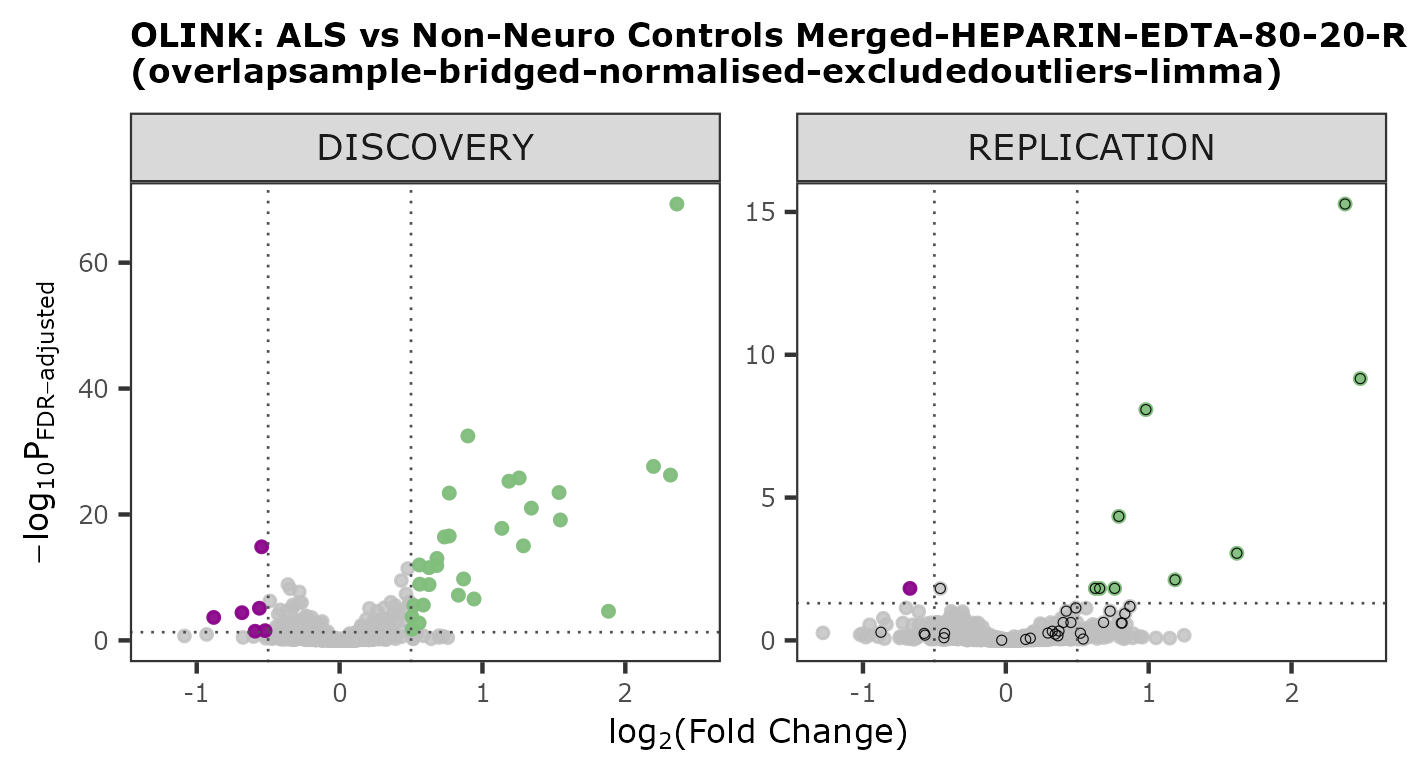

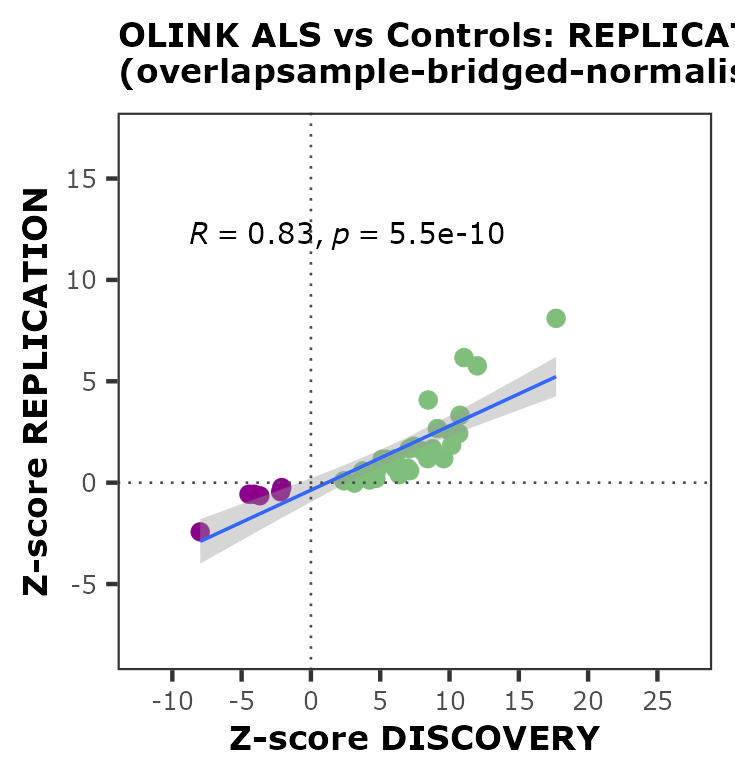

In [4]:
from IPython.display import display
from PIL import Image

display(Image.open("HEPARIN_EDTA_updated/wo_Neuro-controls_with_UMAP_correction/ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub.jpeg"))
#display(Image.open("HEPARIN_EDTA/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_REPLICATION_overlapsample-bridged-normalised_PC-corrected-excludedoutliers-limma.volcanoPlot_forPub_withLabel.jpeg"))
display(Image.open("HEPARIN_EDTA_updated/wo_Neuro-controls_with_UMAP_correction/ALSvsControls_REPLICATION_vs_DISCOVERY_signif_prots_overlapsample-bridged-normalised-excludedoutliers-limma.signifProteinsDiscovery.jpeg"))


#### Collate date to compare differential analysis results under different sample incusion +/- UMAP correction

In [ ]:
%%bash
cd HEPARIN_EDTA_updated
mkdir collate_results
cd collate_results

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(NCmisc) # this is needed to calculate Z-score from p-values

data <- fread("../ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt")
data_woUMAP <- fread("../wo_UMAP_correction/ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt")
data_woNeuroC <- fread("../wo_Neuro-controls_with_UMAP_correction/ALS_Non-Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt")

# subset to the top 33 proteins from the main differential analysis (i.e. + UMAP correction and include neuro controls)
data_signif <- data %>% filter(adj.P.Val < 0.05) %>% filter(logFC < -0.5 | logFC > 0.5) %>% mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>% mutate(Analysis = "Baseline")
data_woUMAP_subset <- data_woUMAP %>% mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>% filter(Assay_Panel %in% data_signif$Assay_Panel) %>% mutate(Analysis = "wo_UMAP_corr")
data_woNeuroC_subset <- data_woNeuroC %>% mutate(Assay_Panel = paste(Assay,Panel,sep="_")) %>% filter(Assay_Panel %in% data_signif$Assay_Panel) %>% mutate(Analysis = "wo_NeuroControl_withUMAP")

write.table(data_signif,"Diff_exp_signif_ALSvsNon-Neuro_Neuro_Controls_with_UMAP_corr.txt",sep="\t",quote=F,row.names=F,col.names=T)
write.table(data_woUMAP_subset,"Diff_exp_signif_ALSvsNon-Neuro_Neuro_Controls_without_UMAP_corr.txt",sep="\t",quote=F,row.names=F,col.names=T)
write.table(data_woNeuroC_subset,"Diff_exp_signif_ALSvsNon-Neuro_Controls_with_UMAP_corr.txt",sep="\t",quote=F,row.names=F,col.names=T)

data_all <- rbind(data_signif,data_woUMAP_subset,data_woNeuroC_subset)
# calculate Z-score from p_fdr
data_all$Direction <- ifelse(data_all$logFC > 0, 1, -1)
data_all$Z <- (p.to.Z(data_all$adj.P.Val)) * data_all$Direction
write.table(data_all,"Diff_exp_signif_merged_with_UMAP_corr.txt",sep="\t",quote=F,row.names=F,col.names=T)

# reformat for publication
data_all_tidy <- data_all %>% select(Analysis,Assay_Panel,logFC,adj.P.Val,Z) %>%
                pivot_wider(names_from = Analysis,
                            values_from = c(logFC,adj.P.Val,Z)) %>% data.frame()
write.table(data_all_tidy,"Diff_exp_signif_merged_with_UMAP_corr_REFORMAT.txt",sep="\t",quote=F,row.names=F,col.names=T)                            

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv("HEPARIN_EDTA_updated/collate_results/Diff_exp_signif_merged_with_UMAP_corr_REFORMAT.txt",sep="\t")
data.columns

Index(['Assay_Panel', 'logFC_Baseline', 'logFC_wo_UMAP_corr',
       'logFC_wo_NeuroControl_withUMAP', 'adj.P.Val_Baseline',
       'adj.P.Val_wo_UMAP_corr', 'adj.P.Val_wo_NeuroControl_withUMAP',
       'Z_Baseline', 'Z_wo_UMAP_corr', 'Z_wo_NeuroControl_withUMAP'],
      dtype='object')

In [2]:
data

,Assay_Panel,logFC_Baseline,logFC_wo_UMAP_corr,logFC_wo_NeuroControl_withUMAP,adj.P.Val_Baseline,adj.P.Val_wo_UMAP_corr,adj.P.Val_wo_NeuroControl_withUMAP,Z_Baseline,Z_wo_UMAP_corr,Z_wo_NeuroControl_withUMAP
0,ACTN2_Cardiometabolic,1.096430,1.095565,1.135772,9.447546e-20,6.828078e-20,1.589364e-18,9.095128,9.130346,8.783166
1,ALDH3A1_Inflammation,2.217099,2.219211,2.197223,6.272836e-40,3.066717e-40,2.340868e-28,13.225250,13.278948,11.044106
2,ART3_Cardiometabolic,-0.528841,-0.525366,-0.545493,1.221095e-18,1.679269e-18,1.372024e-15,-8.812753,-8.776977,-7.987949
3,CA3_Cardiometabolic,1.080624,1.072469,1.185402,5.907532e-27,1.633311e-26,5.149187e-26,10.750290,10.656084,10.548724
4,CORO6_Neurology,1.237317,1.245330,1.257065,1.385531e-32,4.855374e-33,1.581782e-26,11.886838,11.974124,10.659066
5,CSRP3_Cardiometabolic,2.190867,2.180707,2.315959,2.561363e-29,4.165797e-29,5.517590e-27,11.241112,11.198098,10.756587
6,DTNB_Oncology,0.563702,0.570252,0.558640,4.165093e-15,1.696762e-15,1.046911e-12,7.849858,7.961711,7.124194
7,DUSP29_Neurology,0.830352,0.822442,0.831415,1.200235e-08,1.514362e-08,6.596580e-08,5.699693,5.659928,5.401826
8,EDA2R_Oncology,0.772541,0.779869,0.767238,2.337313e-22,9.676457e-23,2.649250e-17,9.725942,9.815285,8.461075
9,FGF21_Oncology,0.645550,0.657275,0.541307,1.432404e-02,1.296038e-02,8.934066e-02,2.449033,2.484856,1.698886


## Enrichment analysis: ALS vs controls

In [ ]:
!mkdir HEPARIN_EDTA_updated/EnrichmentAnalysis/

In [ ]:
!mkdir HEPARIN_EDTA_updated/EnrichmentAnalysis/clusterProfiler

### clusterProfiler (Figure 3)

In [ ]:
%%bash
cd HEPARIN_EDTA_updated/EnrichmentAnalysis/clusterProfiler

module load R/4.3.2
R --vanilla --no-save

require(data.table)
require(tidyverse)
library("Hmisc")
library(ggplot2) 
library(ggpubr)
library(ggrepel)
library(broom)
library(grid)
library(gridExtra)
library(ggpubfigs)
# Install clusterProfiler and msigdbr if not already installed
#if (!requireNamespace("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")
#BiocManager::install("clusterProfiler", force=TRUE)
#BiocManager::install("msigdbr", force=TRUE)
library(clusterProfiler)
library(msigdbr)
library(org.Hs.eg.db) # Database for human gene annotations
require(dplyr)

# prepare list of input proteins for analysis
results_limma_excl_ouliers <- fread("../../ALS_Non-Neuro_and_Neuro_Control-Merged-HEPARIN-EDTA-80-20-DISCOVERY_overlapsample-bridged-normalised_PC-corrected-excludedoutliers_analysed-stats-limma.txt")
input <- results_limma_excl_ouliers %>% dplyr::select(Assay,logFC,adj.P.Val)
colnames(input)[1] <- "Gene.symbol"
dim(input)

### padj005_abslogFC05 ###
signif_subset <- input %>%
                 dplyr::filter(adj.P.Val < 0.05)  %>%
                 dplyr::filter(logFC < -0.5 | logFC > 0.5) # FC < 0.71, FC > 1.41
gene_symbols <- signif_subset$Gene.symbol

#### Perform GO Enrichment Analysis ####
# classifiy genes into broader GO terms --> save this as reference (useful to get an overview of GO term distribution in gene set)
# might be able to use this to narrow down results downstream for plotting
ggo_bp <- groupGO(gene = gene_symbols,
               keyType = "SYMBOL",
               OrgDb    = org.Hs.eg.db,
               ont      = "BP",
               level    = 6, # Set GO level (higher level = broader terms)
               readable = TRUE) %>% data.frame()
               
ggo_mf <- groupGO(gene = gene_symbols,
               keyType = "SYMBOL",
               OrgDb    = org.Hs.eg.db,
               ont      = "MF",
               level    = 6, # Set GO level (higher level = broader terms)
               readable = TRUE) %>% data.frame()

ggo_cc <- groupGO(gene = gene_symbols,
               keyType = "SYMBOL",
               OrgDb    = org.Hs.eg.db,
               ont      = "CC",
               level    = 6, # Set GO level (higher level = broader terms)
               readable = TRUE) %>% data.frame()
               
ggo_all <- rbind(ggo_bp,ggo_mf,ggo_cc)
ggo_all_over1 <- ggo_all %>% dplyr::filter(Count > 1) # consider this the parent grouping of GO terms given the list of genes
write.table(ggo_all, "GO_ALL_gene_term_classification_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)

go_results <- enrichGO(gene = gene_symbols, 
                       OrgDb = org.Hs.eg.db, 
                       keyType = "SYMBOL",
                       ont = "ALL",       # Use "ALL" for BP, CC, and MF
                       pAdjustMethod = "BH", 
                       pvalueCutoff = 0.05, 
                       qvalueCutoff = 0.05, 
                       readable = TRUE)

simplified_go_results <- simplify(go_results,
                             cutoff = 0.4,          # Adjust similarity cutoff (default is 0.7); the smaller the cutoff, the more specific terms will be kept i.e. smaller n terms retained
                             by = "p.adjust",       # Simplify based on adjusted p-values
                             select_fun = min,      # Select most significant term per group
                             measure = "Wang")      # Use "Wang" for semantic similarity

go_results <- go_results@result
simplified_go_results <- simplified_go_results@result

go_results_parent_terms <- go_results %>% dplyr::filter(go_results$ID %in% ggo_all_over1$ID)

dim(go_results)
dim(simplified_go_results)

# calculate fold enrichment (i.e. (n genes from query list that are in the pathway / n genes in input list) / (n total genes in pathway / n total genes in the background) )
go_results <- go_results %>%
                 dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                 dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                 dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                        N_gene_in_input = as.integer(N_gene_in_input),
                        N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                        N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                 dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

simplified_go_results <- simplified_go_results %>%
                 dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                 dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                 dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                        N_gene_in_input = as.integer(N_gene_in_input),
                        N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                        N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                 dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

# Export results to a CSV
write.table(go_results, "GO_ALL_ORA_padj005.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(simplified_go_results, "GO_ALL_Enrichment_simplified_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)


#### Perform KEGG pathway over-representation analysis ####
# Convert gene symbols to Entrez IDs --> this is needed for enrichKEGG()
gene_list <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
entrez_ids <- gene_list$ENTREZID

kegg_results <- enrichKEGG(gene = entrez_ids,
                           organism = 'hsa',   # hsa stands for Homo sapiens
                           pAdjustMethod = "BH",
                           pvalueCutoff = 0.05,
                           qvalueCutoff = 0.05)
kegg_results_final <- setReadable(kegg_results, 'org.Hs.eg.db', keyType="ENTREZID") %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))
write.table(kegg_results_final , "KEGG_ORA_padj005.txt", sep="\t", quote=F, row.names=F, col.names=T)


#### Perform analysis using the MSigDB collection ####
# Download the desired MSigDB collection (e.g., Hallmark gene sets, H)
msigdb_hallmark <- msigdbr(species = "Homo sapiens", category = "H") 
#c2 <- msigdbr(species = "Homo sapiens", category = "C2")
msigdb_c5_go <- msigdbr(species = "Homo sapiens", category = "C5")
msigdb_c7_immuno <- msigdbr(species = "Homo sapiens", category = "C7")
msigdb_c8_celltype <- msigdbr(species = "Homo sapiens", category = "C8")

msigdb_c2_kegg <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:KEGG")
msigdb_c2_react <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:REACTOME")
msigdb_c2_biocarta <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:BIOCARTA")
msigdb_c2_wp <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:WIKIPATHWAYS")

# Format genes
## Convert msigdbr output to a list for use in enricher()
msigdb_list_h <- msigdb_hallmark %>% 
                 dplyr::select(gs_name, gene_symbol)

msigdb_list_c2_kegg <- msigdb_c2_kegg %>% 
                       dplyr::select(gs_name, gene_symbol)   
                  
msigdb_list_c2_react <- msigdb_c2_react %>% 
                       dplyr::select(gs_name, gene_symbol)  

msigdb_list_c2_biocarta <- msigdb_c2_biocarta %>% 
                       dplyr::select(gs_name, gene_symbol)  

msigdb_list_c2_wp <- msigdb_c2_wp %>% 
                       dplyr::select(gs_name, gene_symbol)
                       
msigdb_list_c5 <- msigdb_c5_go %>% 
                  dplyr::select(gs_name, gene_symbol)  
                  
msigdb_list_c7 <- msigdb_c7_immuno %>% 
                  dplyr::select(gs_name, gene_symbol)  

msigdb_list_c8 <- msigdb_c8_celltype %>% 
                  dplyr::select(gs_name, gene_symbol)  

                  
## Run enrichment analysis
msigdb_enrichment_h <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_h,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))
                              
msigdb_enrichment_c2_kegg <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c2_kegg,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

msigdb_enrichment_c2_react <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c2_react,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

msigdb_enrichment_c2_biocarta <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c2_biocarta,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

msigdb_enrichment_c2_wp <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c2_wp,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))
                              
msigdb_enrichment_c5 <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c5,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

msigdb_enrichment_c7 <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c7,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))

msigdb_enrichment_c8 <- enricher(gene = gene_symbols,
                              TERM2GENE = msigdb_list_c8,
                              pvalueCutoff = 0.05,
                              qvalueCutoff = 0.05) %>% data.frame() %>%
                      dplyr::mutate(tmp = GeneRatio) %>% separate(tmp, c("N_gene_query_in_pathway","N_gene_in_input"), "/") %>%
                      dplyr::mutate(tmp = BgRatio) %>% separate(tmp, c("N_total_gene_in_pathway","N_total_gene_in_bg"), "/") %>%
                      dplyr::mutate(N_gene_query_in_pathway = as.integer(N_gene_query_in_pathway),
                             N_gene_in_input = as.integer(N_gene_in_input),
                             N_total_gene_in_pathway = as.integer(N_total_gene_in_pathway),
                             N_total_gene_in_bg = as.integer(N_total_gene_in_bg)) %>%
                      dplyr::mutate(Fold_enrichment = (N_gene_query_in_pathway/N_gene_in_input) / (N_total_gene_in_pathway/N_total_gene_in_bg))
## Save results
write.table(msigdb_enrichment_h, "MSIGDB_hallmark_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c2_kegg, "MSIGDB_c2_kegg_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c2_react, "MSIGDB_c2_reactome_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c2_biocarta, "MSIGDB_c2_biocarta_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c2_wp, "MSIGDB_c2_wp_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c5, "MSIGDB_c5_GO_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c7, "MSIGDB_c7_immuno_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)
write.table(msigdb_enrichment_c8, "MSIGDB_c8_celltype_geneset_ORA_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)




# plot combined results for go, kegg, react, wp
GO <- simplified_go_results %>% dplyr::mutate(Category = paste("GO:",ONTOLOGY, sep=""))
KEGG <- kegg_results_final %>% dplyr::mutate(Category = "KEGG")
REACT <- msigdb_enrichment_c2_react %>% dplyr::mutate(Category = "REACTOME")

colsToKeep <- colnames(KEGG)[which(colnames(KEGG) %in% colnames(GO))]
GO <- GO %>% dplyr::select(all_of(colsToKeep))
KEGG <- KEGG %>% dplyr::select(all_of(colsToKeep))
REACT <- REACT %>% dplyr::select(all_of(colsToKeep))
all <- rbind(GO,KEGG,REACT)
all$Description <- gsub("actin binding", "Actin binding", all$Description)
all$Description <- gsub("carbohydrate homeostasis", "Carbohydrate homeostasis", all$Description)
all$Description <- gsub("contractile fiber", "Contractile fiber", all$Description)
all$Description <- gsub("glucose homeostasis", "Glucose homeostasis", all$Description)
all$Description <- gsub("muscle system process", "Muscle system process", all$Description)
all$Description <- gsub("myofibril", "Myofibril", all$Description)
all$Description <- gsub("myofibril assembly", "Myofibril assembly", all$Description)
all$Description <- gsub("non-membrane-bounded organelle assembly", "Non-membrane-bounded organelle assembly", all$Description)
all$Description <- gsub("pseudopodium", "Pseudopodium", all$Description)
all$Description <- gsub("regulation of myoblast proliferation", "Regulation of myoblast proliferation", all$Description)
all$Description <- gsub("response to muscle stretch", "Response to muscle stretch", all$Description)
all$Description <- gsub("response to peptide hormone", "Response to peptide hormone", all$Description)
all$Description <- gsub("striated muscle cell development", "Striated muscle cell development", all$Description)
all$Description <- gsub("structural constituent of muscle", "Structural constituent of muscle", all$Description)
all$Description <- gsub("REACTOME_ASSEMBLY_AND_CELL_SURFACE_PRESENTATION_OF_NMDA_RECEPTORS","Assembly and cell surface presentation of NMDA receptors", all$Description)
all$Description <- gsub("REACTOME_CREB1_PHOSPHORYLATION_THROUGH_NMDA_RECEPTOR_MEDIATED_ACTIVATION_OF_RAS_SIGNALING","CREB1 phosphorylation through NMDA receptor-mediated activation of RAS signaling", all$Description)
all$Description <- gsub("REACTOME_LONG_TERM_POTENTIATION","Long-term potentiation", all$Description)
all$Description <- gsub("REACTOME_MUSCLE_CONTRACTION","Muscle contraction", all$Description)
all$Description <- gsub("REACTOME_NEGATIVE_REGULATION_OF_NMDA_RECEPTOR_MEDIATED_NEURONAL_TRANSMISSION","Negative regulation of NMDA receptor-mediated neuronal transmission", all$Description)
all$Description <- gsub("REACTOME_RAS_ACTIVATION_UPON_CA2_INFLUX_THROUGH_NMDA_RECEPTOR","RAS activation upon calcium influx through NMDA receptor", all$Description)
all$Description <- gsub("REACTOME_STRIATED_MUSCLE_CONTRACTION","Striated muscle contraction", all$Description)
all$Description <- gsub("REACTOME_SMOOTH_MUSCLE_CONTRACTION","Smooth muscle contraction", all$Description)
all$Description <- gsub("REACTOME_UNBLOCKING_OF_NMDA_RECEPTORS_GLUTAMATE_BINDING_AND_ACTIVATION","Unblocking of NMDA receptors glutamate binding and activation", all$Description)
write.table(all, "InputForPlotting_clusterProfiler_enrichment_results_ALS_control_diff_exp_analysis_padj005_abslogFC05.txt", sep="\t", quote=F, row.names=F, col.names=T)


# hex code for ito_seven color palette
#0072B2, #D55E00, #009E73, #CC79A7, #56B4E9, #E69F00, #F0E442

cols = c("GO:BP" = "#0072B2", "GO:MF" = "#D55E00", "GO:CC" = "#009E73", "REACTOME" = "#CC79A7", "KEGG" = "#56B4E9")

# plot
all$Category <- factor(all$Category, levels=c("GO:BP","GO:MF","GO:CC","REACTOME","KEGG"))
all <- all %>% group_by(Category) %>% dplyr::arrange(Category,desc(Fold_enrichment)) %>% data.frame()

all_tidy <- all %>% dplyr::select(geneID,Category,Description,p.adjust,Fold_enrichment) %>% group_by(Category) %>% dplyr::arrange(Category,Fold_enrichment) %>% data.frame()
all_tidy
all_tidy$index <- rev(1:dim(all_tidy)[1])
all_tidy$index <- factor(all_tidy$index, levels=rev(1:28))
all_tidy$Description <- factor(all_tidy$Description, levels=c("Response to peptide hormone","Non-membrane-bounded organelle assembly","Carbohydrate homeostasis","Glucose homeostasis",
                                                              "Muscle system process","Response to muscle stretch","Regulation of myoblast proliferation","Striated muscle cell development",
                                                              "Myofibril assembly","Actin binding","Structural constituent of muscle","Contractile fiber","Myofibril","Pseudopodium",
                                                              "Assembly and cell surface presentation of NMDA receptors","Muscle contraction","Smooth muscle contraction",
                                                              "CREB1 phosphorylation through NMDA receptor-mediated activation of RAS signaling","Long-term potentiation",
                                                              "Negative regulation of NMDA receptor-mediated neuronal transmission","Unblocking of NMDA receptors glutamate binding and activation",
                                                              "RAS activation upon calcium influx through NMDA receptor","Striated muscle contraction","Adrenergic signaling in cardiomyocytes",
                                                              "Cardiac muscle contraction","Dilated cardiomyopathy","Hypertrophic cardiomyopathy","Cytoskeleton in muscle cells"))

muscle_process <- c("Muscle system process","Striated muscle cell development","Myofibril assembly","Myofibril",
                    "Contractile fiber","Structural constituent of muscle","Actin binding","Muscle contraction",
                    "Smooth muscle contraction","Striated muscle contraction","Cardiac muscle contraction",
                    "Regulation of myoblast proliferation","Cytoskeleton in muscle cells","Adrenergic signaling in cardiomyocytes",
                    "Dilated cardiomyopathy","Hypertrophic cardiomyopathy","Response to muscle stretch") %>% data.frame() %>%
                    mutate(Broader_grouping = "Muscle Development, Assembly and Maintenance")
homeostasis <- c("Response to peptide hormone","Glucose homeostasis","Carbohydrate homeostasis") %>% data.frame() %>%
                    mutate(Broader_grouping = "Hormonal and Homeostatic Regulation")
synaptic <- c("Assembly and cell surface presentation of NMDA receptors","Negative regulation of NMDA receptor-mediated neuronal transmission",
              "Unblocking of NMDA receptors glutamate binding and activation","CREB1 phosphorylation through NMDA receptor-mediated activation of RAS signaling",
              "RAS activation upon calcium influx through NMDA receptor","Long-term potentiation","Non-membrane-bounded organelle assembly","Pseudopodium") %>% data.frame() %>%
                    mutate(Broader_grouping = "Cell Signalling and Neuronal Synaptic Transmission")
group_map <- rbind(muscle_process,homeostasis,synaptic)
colnames(group_map)[1] <- "Description"

all_tidy <- merge(all_tidy, group_map, by="Description") %>% group_by(Category) %>% dplyr::arrange(Category,Fold_enrichment) %>% data.frame()
write.table(all_tidy, "InputForPlotting_clusterProfiler_enrichment_results_ALS_control_diff_exp_analysis_padj005_abslogFC05_FINAL_wBroaderGrouping.txt",sep="\t",quote=F,row.names=F, col.names=T)

table(all_tidy$geneID,all_tidy$Broader_grouping)

plot <- ggplot(all_tidy %>% group_by(Category) %>% dplyr::arrange(Category,Description),
               aes(x=Fold_enrichment,y=Description, colour = Category, size=-log10(p.adjust))) +
        geom_point() + 
        #scale_fill_manual(values = friendly_pal("ito_seven")) +
        scale_color_manual(values = cols) +
        scale_size_continuous(name="-log10(FDR p-values)", breaks = seq(0, 13, 2)) +
        scale_x_continuous(limits=c(-5,130), breaks = seq(0, 125, 25)) +
        facet_grid(rows = vars(Category), scales='free', space='free') +
        #ggtitle("Protein interactor gene enrichment analysis: clusterProfiler") +
        xlab("Fold enrichment") + 
        theme_bw() +
        theme(strip.text.x = element_text(color = "white", face = "bold", size = 6, margin = margin(b = 5, t = 2)), # Bottom & Top padding
              strip.text.y = element_text(color = "white", face = "bold", size = 6, margin = margin(l = 2, r = 2)),  # Left & Right padding
              strip.background = element_rect(colour=NA, fill=NA),
              theme(legend.key.size = unit(0.1, 'cm')),
              legend.title = element_text(size=6, face="bold"),
              legend.text = element_text(size=6),
              panel.grid.major.x = element_blank(),
              panel.grid.minor.x = element_blank(),
              panel.grid.major.y = element_blank(),
              panel.grid.minor.y = element_blank(),
              axis.text=element_text(size=6),
              axis.title.y=element_blank(),
              axis.title=element_text(size=8,face="bold"),
              plot.title = element_text(face = "bold", size = 8),
              text = element_text(family = "Helvetica", color="black"),
              plot.margin = margin(5.5, 5.5, 5.5, 5.5, "pt"))

g <- ggplot_gtable(ggplot_build(plot))
stripr <- which(grepl('strip-r', g$layout$name))
fills <- c("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#56B4E9")
k <- 1
for (i in stripr) {
j <- which(grepl('rect', g$grobs[[i]]$grobs[[1]]$childrenOrder))
g$grobs[[i]]$grobs[[1]]$children[[j]]$gp$fill <- fills[k]
k <- k+1
}

jpeg("clusterProfiler_enrichment_results_ALS_control_diff_exp_analysis_padj005_abslogFC05.jpeg", width=6.5,height=6.5, units="in", res=600) # or jpeg, etc.
grid.draw(g)
dev.off()

Muscle Development and Assembly
(ACTN2, CORO6, CSRP3, KLHL41, LEP, MEGF10, MYBPC1, MYBPC2, MYL3, MYLPF, MYOM2, MYOM3, NEB, TNNI3, TPM3, TTN)
	Muscle system process
	Striated muscle cell development
	Myofibril assembly
	Myofibril
	Contractile fiber
	Structural constituent of muscle
	Actin binding
	Muscle contraction
	Smooth muscle contraction
	Striated muscle contraction
	Cardiac muscle contraction
	Regulation of myoblast proliferation
	Cytoskeleton in muscle cells
	Adrenergic signaling in cardiomyocytes
	Dilated cardiomyopathy
	Hypertrophic cardiomyopathy
	Response to muscle stretch

Hormonal and Homeostatic Regulation
(ACTN2, CSRP3, DUSP29, FGF21, LEP, NEFL)
	Response to peptide hormone
	Glucose homeostasis
	Carbohydrate homeostasis

Cell Signaling and Neuronal Synaptic Transmission
(ACTN2, CSRP3, KLHL41, MYOM2, NEB, NEFL, TTN)
	Assembly and cell surface presentation of NMDA receptors
	Negative regulation of NMDA receptor-mediated neuronal transmission
	Unblocking of NMDA receptors glutamate binding and activation
	CREB1 phosphorylation through NMDA receptor-mediated activation of RAS signaling
	RAS activation upon calcium influx through NMDA receptor
	Long-term potentiation
	Non-membrane-bounded organelle assembly
	Pseudopodium

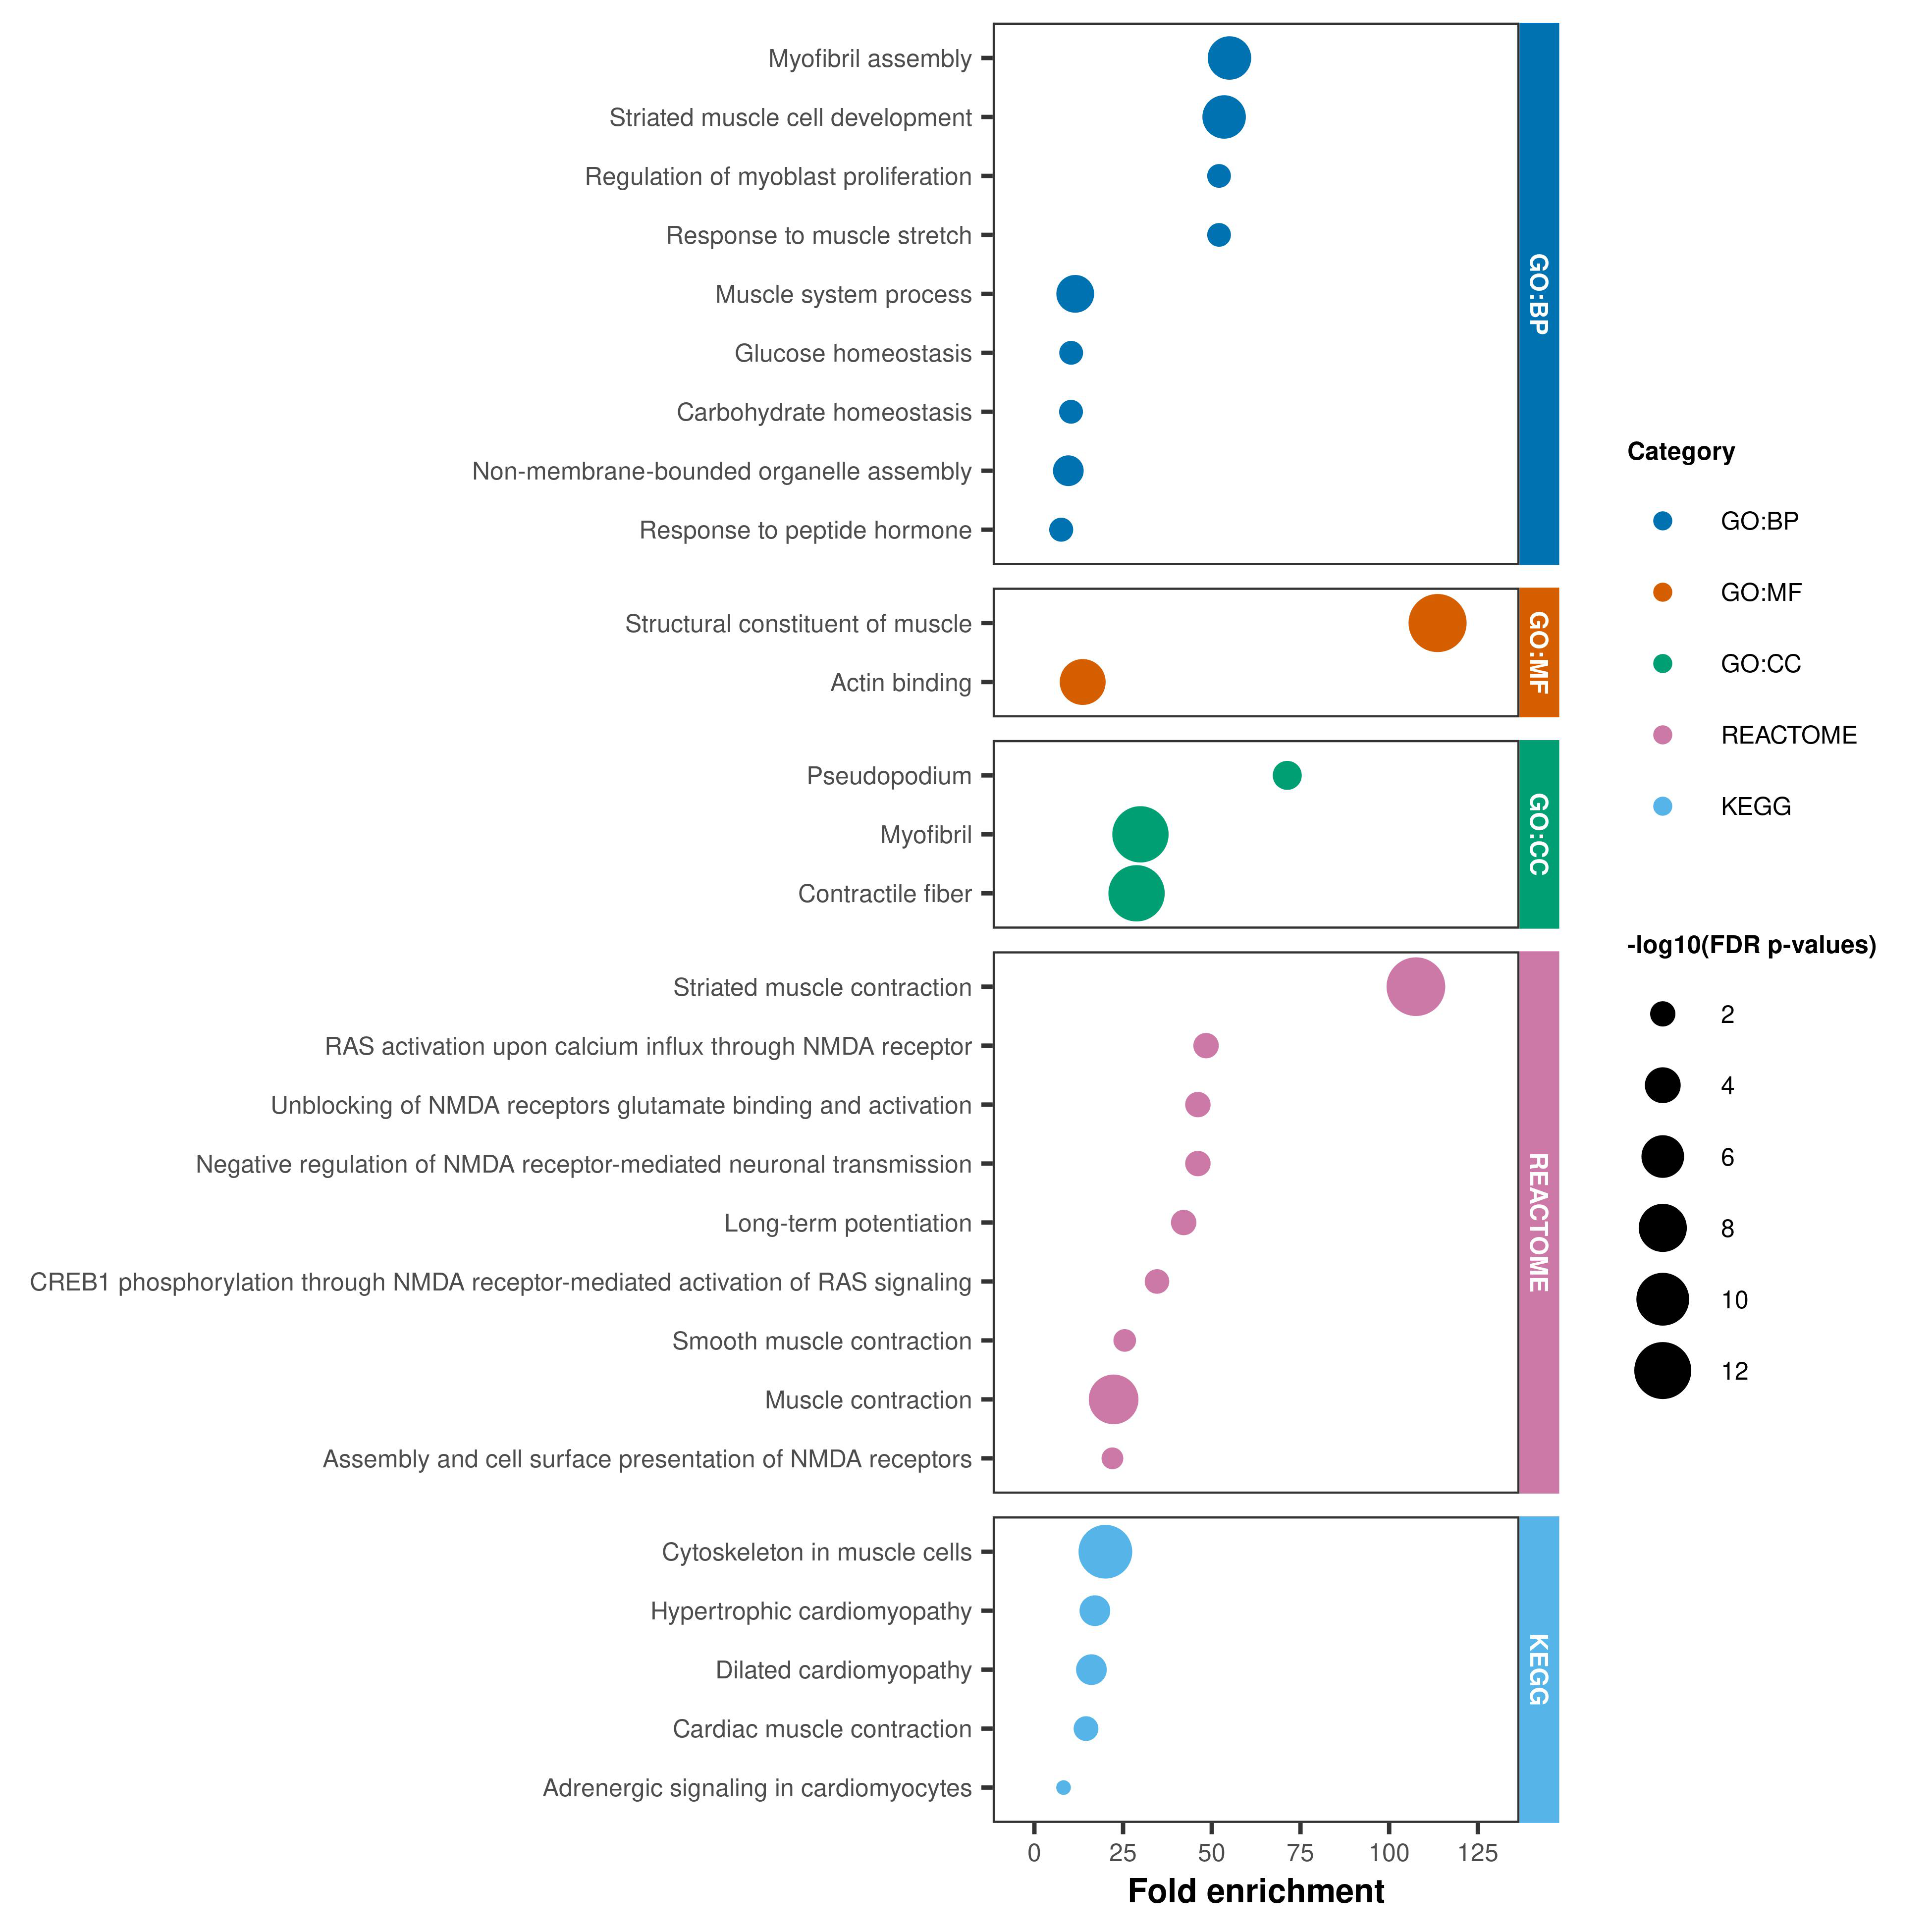

In [3]:
from IPython.display import display
from PIL import Image

display(Image.open("HEPARIN_EDTA_updated/EnrichmentAnalysis/clusterProfiler/clusterProfiler_enrichment_results_ALS_control_diff_exp_analysis_padj005_abslogFC05.jpeg"))